# core

> Fill in a module description here

In [1]:
#| default_exp core
%load_ext autoreload
%autoreload 2

In [2]:
#| hide
import sys
import os
import matplotlib.pyplot as plt

sys.path.append("..")

import numpy as np

from scipy.interpolate import CubicSpline

from CIGNN_experimental.unipen_renderer.parser import Parser
from CIGNN_experimental.unipen_renderer.strokes_to_image_converter import Strokes2ImageConverter
splines = np.load("../CIGNN_experimental/unipen_renderer/unipen_strokes.npy", allow_pickle=True).item()
splines.keys()

dict_keys([98, 117, 116, 45, 102, 101, 119, 109, 111, 114, 103, 105, 110, 33, 65, 121, 100, 63, 68, 39, 108, 115, 97, 99, 104, 46, 58, 59, 57, 56, 55, 43, 52, 53, 54, 49, 50, 51, 48, 42, 81, 85, 69, 82, 83, 75, 74, 79, 84, 72, 87, 89, 90, 73, 77, 67, 106, 113, 107, 112, 118, 120, 122, 88, 36, 34, 66, 70, 71, 76, 78, 80, 44, 86, 61, 64, 40, 41, 125, 35, 123, 37, 38, 47, 60, 96, 126, 93, 94, 124, 62, 91, 92, 95])

In [3]:
# Reduce the problem by only considering three classes: capital A, B and C 
splines = {cls: splines[cls] for cls in [65, 66, 67, 68, 69]}

# Choose one prototype per class 
prototypes = []
for cls in list(splines.keys()):
    # Keep track of how many recordings we have for each class 
    print(f"Class {cls}: {len(splines[cls])} #items")

    # Randomly choose one sample of each class as prototype.
    # For now just use one prototype per class
    rand_idx = np.random.choice(len(splines[cls]))  
    prototypes.append(splines[cls][rand_idx])

Class 65: 1401 #items
Class 66: 891 #items
Class 67: 967 #items
Class 68: 931 #items
Class 69: 1681 #items


In [60]:
# Load the transformations

# I have put them in a separate file now to later include them into the pipeline
from CIGNN_experimental.stroke_transforms import random_move, random_move_stroke, smooth_strokes, shorten, prolong, merge_points, skip_points, merge_strokes, split_strokes


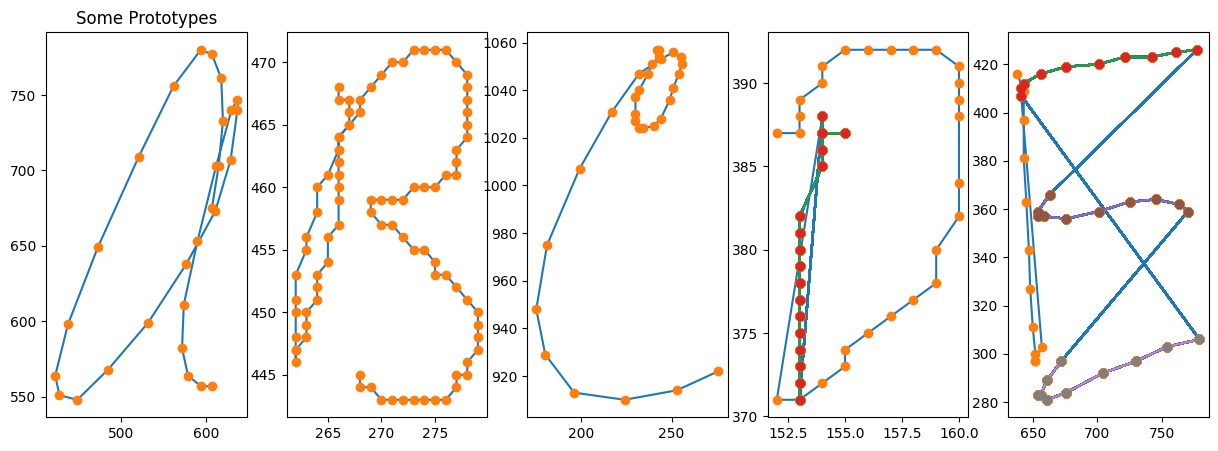

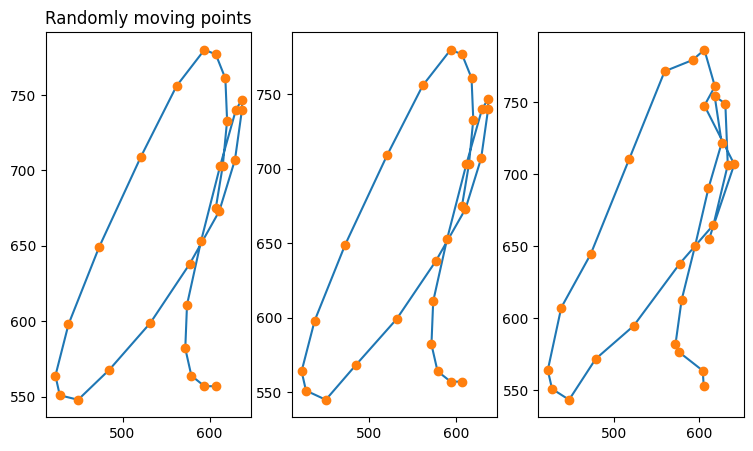

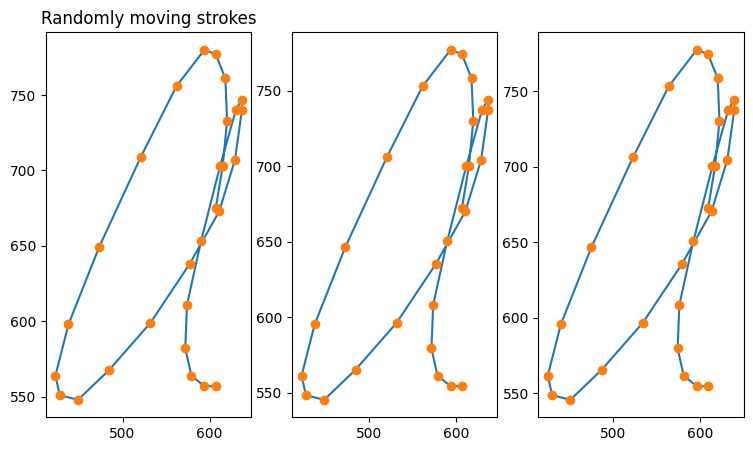

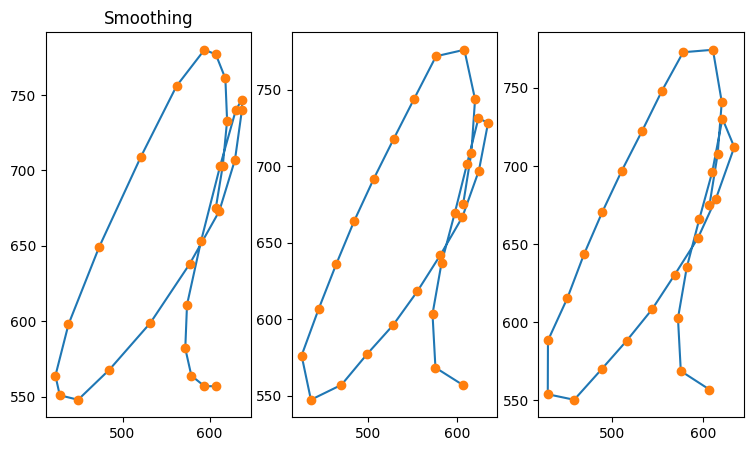

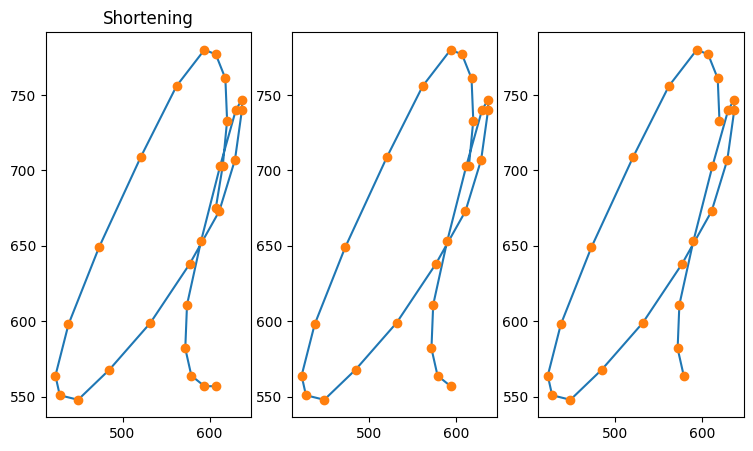

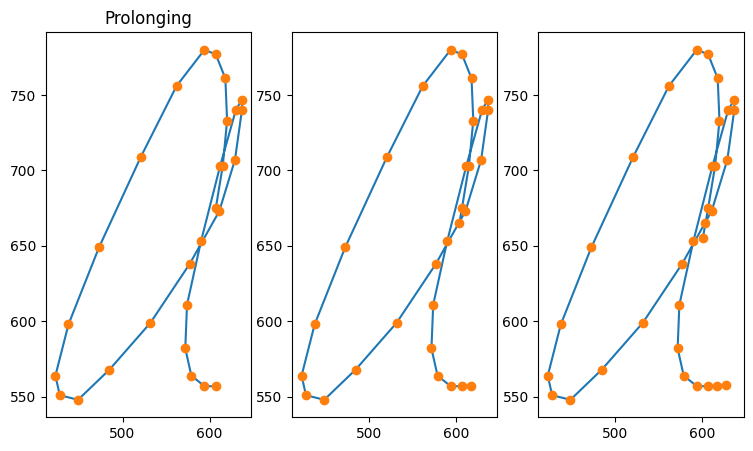

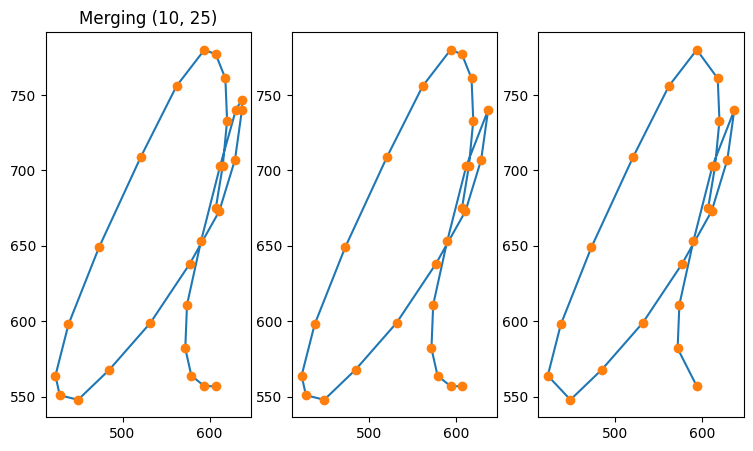

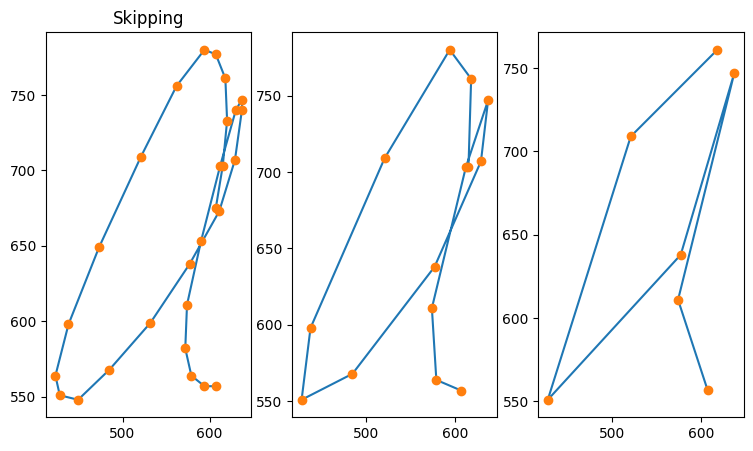

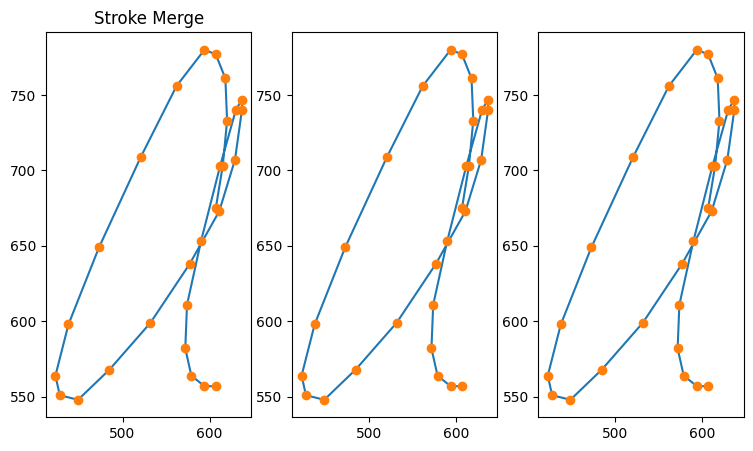

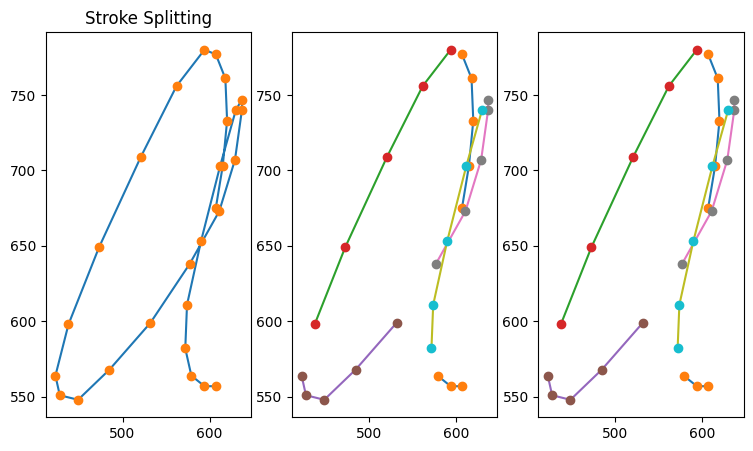

In [65]:
def render_samples(samples, title=""):
    fig, axes = plt.subplots(nrows=1, ncols=len(samples), figsize=(len(samples) * 3, 5))
    axes[0].title.set_text(title)
    
    for idx, sample in enumerate(samples):
        for stroke in sample:
            arr_stroke = np.array(stroke)
            axes[idx].plot(arr_stroke[:, 0], arr_stroke[:, 1])
            axes[idx].plot(arr_stroke[:, 0], arr_stroke[:, 1], "o")

    
    fig.show()
    
render_samples(prototypes, "Some Prototypes")
render_samples([prototypes[0], random_move(prototypes[0]), random_move(prototypes[0], p=.8)], "Randomly moving points")
render_samples([prototypes[0], random_move_stroke(prototypes[0], max_dist=(3, 3)), random_move_stroke(prototypes[0], max_dist=(6, 6))], "Randomly moving strokes")
render_samples([prototypes[0], smooth_strokes(prototypes[0]), smooth_strokes(smooth_strokes(prototypes[0]))], "Smoothing")
render_samples([prototypes[0], shorten(prototypes[0]), shorten(shorten(prototypes[0]))], "Shortening")
render_samples([prototypes[0], prolong(prototypes[0]), prolong(prolong(prototypes[0]))], "Prolonging")
render_samples([prototypes[0], merge_points(prototypes[0], 10), merge_points(prototypes[0], 25)], "Merging (10, 25)")
render_samples([prototypes[0], skip_points(prototypes[0]), skip_points(skip_points(prototypes[0]))], "Skipping")
render_samples([prototypes[0], merge_strokes(prototypes[0]), merge_strokes(merge_strokes(prototypes[0]))], "Stroke Merge")
render_samples([prototypes[0], split_strokes(prototypes[0]), split_strokes(split_strokes(prototypes[0]))], "Stroke Splitting")



In [8]:
# Crossover methods

def linear_interpolation(start, end, num_points=3):
    """
    Perform linear interpolation between two points. This method can be used in cases where spline-fitting is impossible when splines have <3 points.
    This method can fail if start == end!

    Args: 
        start: x-y-tuple of the starting point
        end: x-y-tuple of the ending point
        num_points: How many points should be interpolated

    Returns:
        List of interpolated points (which can be used for spline fitting afterwards)
    """

    if start[0] == end[0] and start[1] == end[1]:
        raise ValueError(f"Can not interpolate {start} - {end}. Aborting.")

    xs = np.linspace(start[0], end[0], num=num_points)
    ys = np.linspace(start[1], end[1], num=num_points)

    return list(zip(xs, ys))

def spline_crossover(prototype1, prototype2):
    """
    Perform spline-based crossover between two prototypes.

    Args:
        prototype1: First parent prototype (list of strokes).
        prototype2: Second parent prototype (list of strokes).
        num_points: Number of points to sample from the combined spline.

    Returns:
        offspring: New prototype generated from the crossover.
    """
    offspring = []

    for stroke1, stroke2 in zip(prototype1, prototype2):
    
        if len(stroke1) < 3:
            # If the stroke consists of only a single value we simply return the other stroke
            if len(stroke1) == 1:
                return stroke2
            else:
                # Attempt an interpolation
                stroke1 = linear_interpolation(stroke1[0], stroke1[-1])
        if len(stroke2) < 3:
            # If the stroke consists of only a single value we simply return the other stroke
            if len(stroke2) == 1:
                return stroke1
            else:
                # Attempt an interpolation
                stroke2 = linear_interpolation(stroke2[0], stroke2[-1])
        # Fit cubic splines to both parent strokes
        points1 = np.array(stroke1)
        points2 = np.array(stroke2)
        t1 = np.linspace(0, 1, len(points1))
        t2 = np.linspace(0, 1, len(points2))
        cs_x1 = CubicSpline(t1, points1[:, 0])
        cs_y1 = CubicSpline(t1, points1[:, 1])
        cs_x2 = CubicSpline(t2, points2[:, 0])
        cs_y2 = CubicSpline(t2, points2[:, 1])

        # Combine the splines (e.g., using single-point crossover)
        t_combined = np.linspace(0, 1, (len(stroke1) + len(stroke2)) // 2)
        x_combined = (cs_x1(t_combined) + cs_x2(t_combined)) / 2
        y_combined = (cs_y1(t_combined) + cs_y2(t_combined)) / 2

        # Create the offspring stroke
        offspring_stroke = list(zip(x_combined, y_combined))
        offspring.append(offspring_stroke)

    return offspring

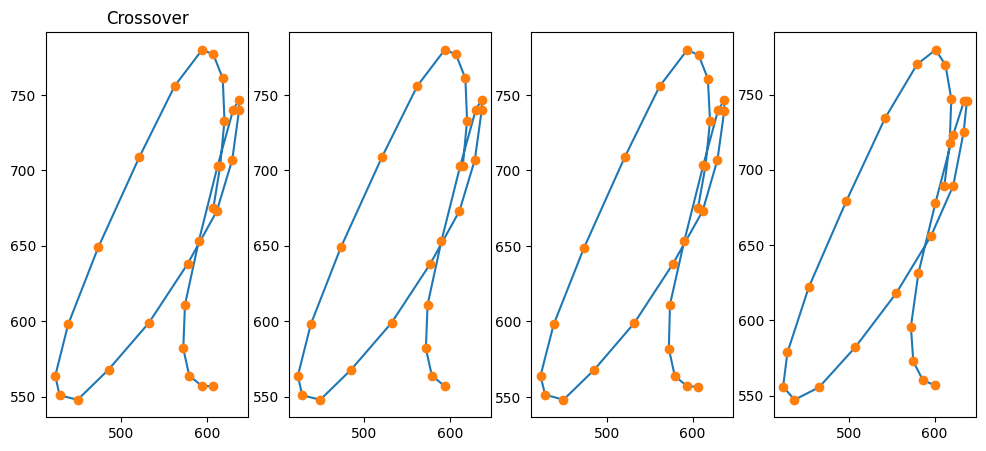

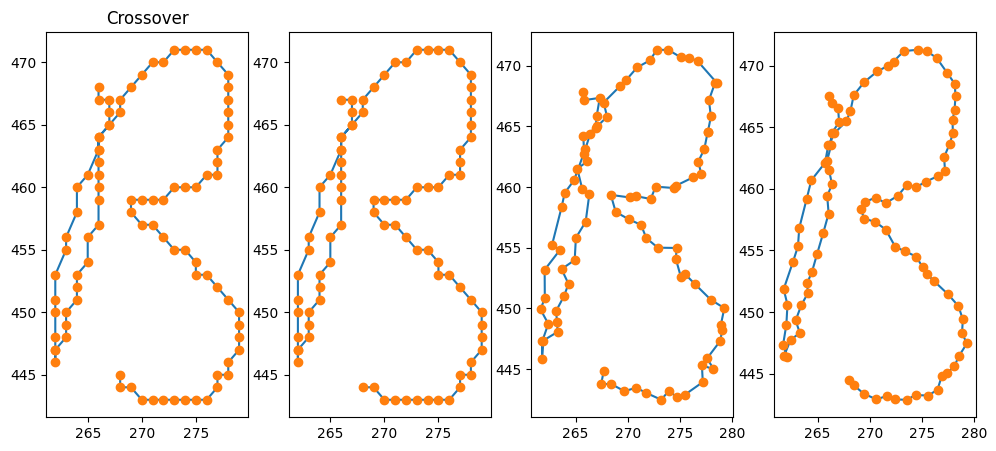

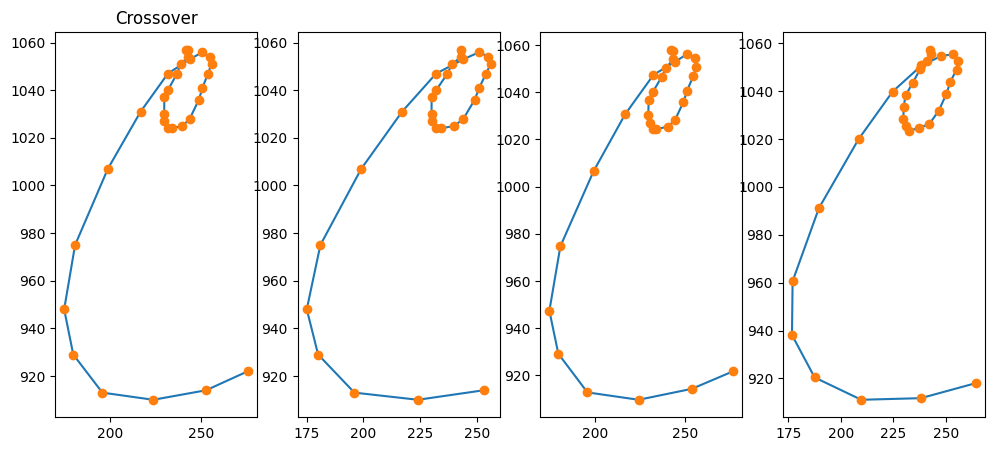

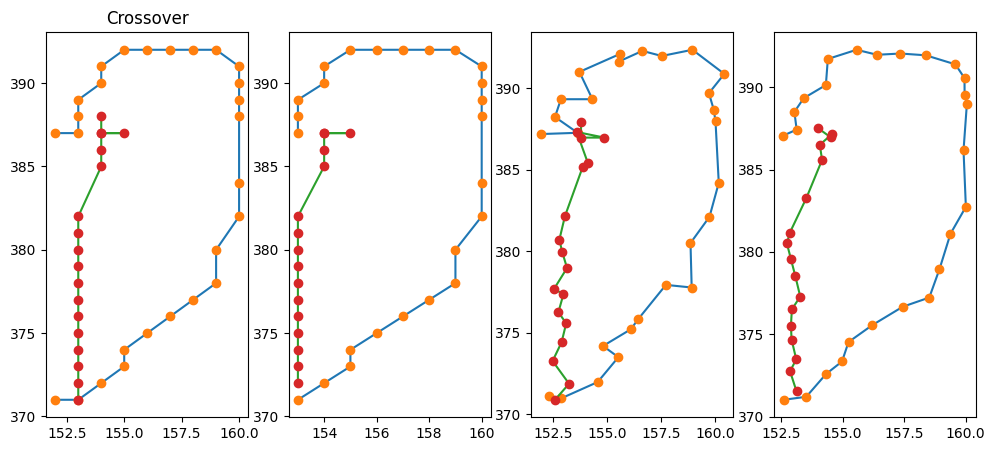

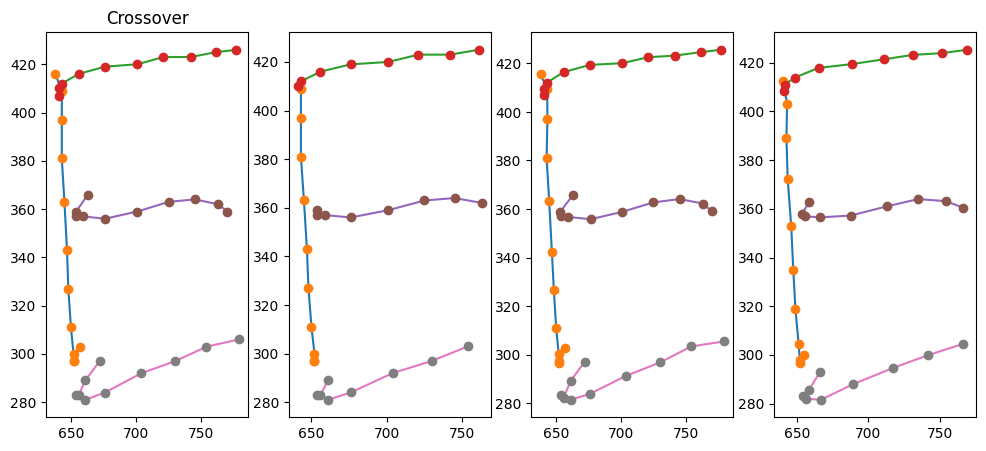

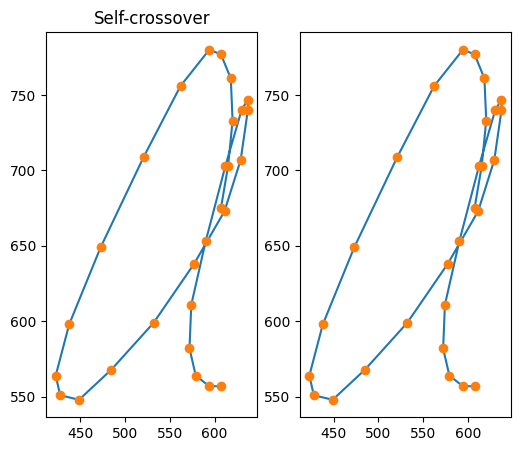

In [9]:
for i in range(len(prototypes)):
        
    render_samples([prototypes[i], shorten(prototypes[i]), random_move(prototypes[i], max_dist=(.3, .3)), spline_crossover(shorten(prototypes[i]), random_move(prototypes[i], max_dist=(.3, .3)))], "Crossover")

# Sanity testing
render_samples([prototypes[0], spline_crossover(prototypes[0], prototypes[0])], "Self-crossover")

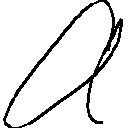

In [10]:
s2i = Strokes2ImageConverter()
#s2i.strokes_to_image(strokes=prototypes[0])
#s2i.strokes_to_image(strokes=prototypes[1])
#s2i.strokes_to_image(strokes=merge_points(spline_crossover(shorten(prototypes[i]), merge_points(prototypes[i], 10)), distance_threshold=10), padding=(5, 5))
img = s2i.strokes_to_image(strokes=spline_crossover(shorten(prototypes[0]), prototypes[0])).convert("L")
img

# This block can be used to show some interpolations between samples, including those across character classes



At this point it is possible to generate, mutate and cross-over samples for each character class. The next goal is to combine these steps on a population resembling a single generation of the evolutionary algorithm. Creating the first generation of samples must be done using only the prototypes of each character class - perhaps with some first mutations. 

In [11]:
from dataclasses import dataclass, field


@dataclass
class Sample():
    fitness: float
    origin: int 
    strokes: list[list[tuple[float, float]]] = field(default_factory=list)

# Usage example
# s = Sample(1.4, 1, [[(3, 2), (3, 3)], [(1,1)]])
    

In [58]:
def mutate(population: list[Sample], p: float = 0.2, mutation_params={}) -> list[Sample]:
    
    mutated_population = []
    for sample in population: 
        if np.random.rand() < p*100:

            new_strokes = []
            # Randomly choose the mutation to apply
            # mut_idx = np.random.randint(1) + 4
            mut_idx = 0

            if mut_idx == 0:
                new_strokes = random_move(sample.strokes, max_dist=(1,1))
            elif mut_idx == 1:
                new_strokes = random_move_stroke(sample.strokes, max_dist=(3, 3))
            elif mut_idx == 2:
                new_strokes = smooth_strokes(sample.strokes)
            elif mut_idx == 3:
                new_strokes = shorten(sample.strokes)
            elif mut_idx == 4:
                new_strokes = prolong(sample.strokes)
            elif mut_idx == 5:
                new_strokes = merge_points(sample.strokes)
            elif mut_idx == 6:
                new_strokes = skip_points(sample.strokes)
            elif mut_idx == 7:
                new_strokes = merge_strokes(sample.strokes, distance_threshold=1e6)
            elif mut_idx == 8: 
                new_strokes = split_strokes(sample.strokes)
            else:
                new_strokes = sample.strokes

            mutated_population.append( Sample(fitness=sample.fitness, origin=sample.origin, strokes=new_strokes))
            

        else:
            mutated_population.append(sample)
        
    return mutated_population

def crossover(population: list[Sample]):

    probabilities = [sample.fitness for sample in population]
    normalized_probabilities = probabilities / np.sum(probabilities) # These can never be negative
    pairs = np.random.choice(population, size=(len(population), 2), p=normalized_probabilities)

    next_generation: list[Sample] = []
    # At this point we have pairs of shape (pop_size, 2)
    for p1, p2 in pairs:         
        next_generation_strokes = spline_crossover(p1.strokes, p2.strokes)
        next_generation.append(Sample(1.0, p1.origin, next_generation_strokes))
    
    return next_generation    

# Preparing datasets for pytorch

With the data prepared it is now time to make it available as `Dataset` and `DataLoader` for the training process. A given population can be converted into a new dataset and the only thing to be aware of is that the `origin` of each sample corresponds to the original prototype which does not neccessarily correspond to a class (several prototypes can exist for the same character class). However, to start the experiments we agreed to stick with one prototype per class, which means that `origin` can be considered a class label.

The code below also covers the initial step required to generate the fist generation of samples. Unlike the subsequent evolutions this step is particular because $N_{pop} \gg N_{proto}$

[[(266, 468), (266, 467), (267, 467), (267, 466), (267, 465), (266, 464), (266, 463), (266, 462), (266, 461), (266, 460), (266, 459), (266, 457), (265, 456), (265, 454), (264, 453), (264, 452), (264, 451), (263, 450), (263, 449), (263, 448), (262, 447), (262, 446), (262, 447), (262, 448), (262, 450), (262, 451), (262, 453), (263, 455), (263, 456), (264, 458), (264, 460), (265, 461), (266, 463), (266, 464), (267, 465), (268, 466), (268, 467), (269, 468), (270, 469), (271, 470), (272, 470), (273, 471), (274, 471), (275, 471), (276, 471), (277, 470), (278, 469), (278, 468), (278, 467), (278, 466), (278, 465), (278, 464), (277, 463), (277, 462), (277, 461), (276, 461), (275, 460), (274, 460), (273, 460), (272, 459), (271, 459), (270, 459), (269, 459), (269, 458), (270, 457), (271, 457), (272, 456), (273, 455), (274, 455), (275, 454), (275, 453), (276, 453), (277, 452), (278, 451), (279, 450), (279, 449), (279, 448), (279, 447), (278, 446), (278, 445), (277, 445), (277, 444), (276, 443), (2

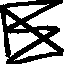

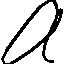

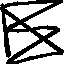

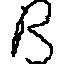

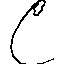

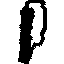

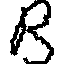

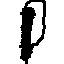

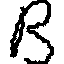

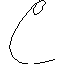

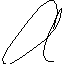

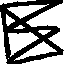

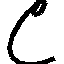

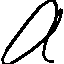

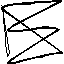

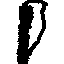

tensor([4, 0, 4, 1, 2, 3, 1, 3, 1, 2, 0, 4, 2, 0, 4, 3])


In [73]:
import torch
from numpy import ndarray
from torch.utils.data import Dataset, DataLoader




def next_generation(population: ndarray[Sample]) -> ndarray[Sample]:

    next_gen = np.array([])
    unique_classes = np.unique([sample.origin for sample in population])

    def print_strokes_len(strokes):
        res = []
        for stroke in strokes:
            res.append(len(stroke))
        return res
        
    for cls in unique_classes:
        population_by_class = list(filter(lambda x: x.origin == cls, population))
        print(f"By class: {print_strokes_len(population_by_class[0].strokes)}")
        mutated_population = mutate(population_by_class)
        print(f"After mutation: {print_strokes_len(population_by_class[0].strokes)}")
        offspring = crossover(mutated_population)
        print(f"After crossover: {print_strokes_len(population_by_class[0].strokes)}")

        next_gen = np.concatenate((next_gen, offspring))

    return next_gen


# Use this population for a Dataset
# For this step we render the strokes so the CNNs operate on the images rather than trajectories
class UnipenDataset(Dataset):
    
    def __init__(self, population, device=None, image_size=(64, 64)):
        """
        """
        from torchvision.transforms.functional import pil_to_tensor
        
        self.data = []
        s2i = Strokes2ImageConverter()

        if not device:
            self.device = torch.device("cuda")

        for sample in population:
            img = s2i.strokes_to_image(strokes=sample.strokes, image_size=image_size, smoothing_factor=0.0, stroke_width=np.random.randint(5) + 1).convert("L")
            # Finally, the image needs to be converted to tensors
            tensor = pil_to_tensor(img).to(device)
            self.data.append((tensor, sample.origin))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, label = self.data[idx]
        return img, label

# Create the first generation
# Repeat each prototype for as many times as defined in `n_samples_per_class`, afterwards flatten the list
n_samples_per_class = 100
population = np.array([[Sample(1.0, idx, prototype_strokes)] * n_samples_per_class for idx, prototype_strokes in enumerate(prototypes)]).reshape(-1)
print(population[100].strokes)
new_population = next_generation(population)
print(new_population[100].strokes)

ds = UnipenDataset(new_population)
dl = DataLoader(ds, batch_size=16, shuffle=True)


from torchvision.transforms.functional import to_pil_image
for batch in next(iter(dl)):
    print(batch)
    for sample in batch:
        if sample.shape:  # Sometimes this tries to render a 0-dim image?!
            display(to_pil_image(sample))


In [ ]:
import torch
from torchsummary import summary

from CIGNN_experimental.models.autoencoder.unipen_synth_ae import UnipenSyntheticAutoencoder

device = torch.device("cuda")

ae = UnipenSyntheticAutoencoder()
ae.to(device)

summary(ae, input_size=(3, 128, 128))


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()